# Asset attention, v2.3.0: checks and the GFC / Covid cases

Reads `asset_attention_daily` of the one-pass run v2.3.0 (pinned below; a partial run is
fine, months not yet scored simply have no rows). One row per (DATE, SENTIMENT label,
RavenPack entity) with at least one headline tagging the entity; every entity ever in the
MSCI World universe is covered, membership as of the day is the `IN_UNIVERSE` flag (null
before the first snapshot, 2006-07).

| column | meaning |
|---|---|
| N_STORIES | headlines of the label tagging the entity (any relevance; a story counts once per entity) |
| N_STORIES_REL | of which vendor RELEVANCE ≥ 60 (`min_relevance` 0.6) |
| REL_SUM | Σ RELEVANCE / 100 over those headlines |
| N_HEADLINES | the day's headlines, every label (same on every row of a day) |
| N_LABELLED | the day's headlines of this label |

Attention share of an asset over a label set L: a(i, t) = Σ_{l∈L} N_STORIES / N_HEADLINES
(same denominator for all label sets, so Negative + Positive+neutral = Attention).

Part 1 checks the table (invariants, coverage, membership, relevance); Part 2 looks at the
GFC; Part 3 at Covid. Read-only: nothing is written to the lake.

In [ ]:
import os
from datetime import date

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import find_dotenv, load_dotenv

from datalake import DatalakeIndex

load_dotenv(find_dotenv(usecwd=True))
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_width_chars(220); pl.Config.set_fmt_str_lengths(50)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True})

# ---- data -----------------------------------------------------------------------------
ASSET_ATTENTION_ID = "asset_attention_daily__v2.3.0__paramsfdb20afe__20261002"
DIAGNOSTICS_ID = "day_diagnostics__v2.3.0__paramsf17c46f2__20261002"
UNIVERSE_ID = "universe__v0.1.0__n_entries383947_namemsci_world_source_patha779a7db__20260929"
STUDIES = {                       # label sets: shares of the SAME daily flow (N_HEADLINES)
    "Attention": ("neg", "neu", "pos"),
    "Negative": ("neg",),
    "Positive + neutral": ("neu", "pos"),
}
RELEVANCE_FLOOR = 60              # min_relevance 0.6 on the vendor's 0-100 scale
TOP_N = 20

# ---- cases ----------------------------------------------------------------------------
GFC = {
    "window": (date(2008, 9, 1), date(2008, 10, 31)),     # Lehman -> coordinated cut
    "baseline": (date(2007, 1, 1), date(2007, 6, 30)),    # pre-crisis reference
    "view": (date(2007, 1, 1), date(2009, 12, 31)),
    "events": {"BNP funds frozen": date(2007, 8, 9), "Bear Stearns": date(2008, 3, 14),
               "GSE conservatorship": date(2008, 9, 7), "Lehman": date(2008, 9, 15),
               "TARP signed": date(2008, 10, 3), "Equity trough": date(2009, 3, 9)},
    "names": {                                            # RavenPack entity ids (universe)
        "Lehman Brothers": "A78640", "Bear Stearns": "A94325", "AIG": "0BC29E",
        "Merrill Lynch": "75EE05", "Fannie Mae": "450647", "Freddie Mac": "CD4203",
        "Citigroup": "58CA9A", "Bank of America": "990AD0", "JPMorgan": "619882",
        "Goldman Sachs": "50070E", "Morgan Stanley": "9196A2", "UBS": "B2E2BC",
    },
}
COVID = {
    "window": (date(2020, 2, 24), date(2020, 4, 30)),     # Italy outbreak -> negative WTI
    "baseline": (date(2019, 7, 1), date(2019, 12, 31)),
    "view": (date(2019, 7, 1), date(2021, 6, 30)),
    "events": {"Wuhan lockdown": date(2020, 1, 23), "Italy outbreak": date(2020, 2, 24),
               "WHO pandemic": date(2020, 3, 11), "Unlimited QE / trough": date(2020, 3, 23),
               "Negative WTI": date(2020, 4, 20), "Pfizer efficacy": date(2020, 11, 9)},
    "names": {
        "Delta": "5F2FF7", "American Airlines": "13C3E0", "United Airlines": "6E705B",
        "Lufthansa": "4DA329", "Boeing": "55438C", "Carnival": "067779",
        "Royal Caribbean": "751A74", "Marriott": "385DD4", "Exxon": "E70531",
        "Chevron": "D54E62", "Occidental": "CA212F", "Shell": "890255",
        "Zoom": "362955", "Amazon": "0157B1", "Netflix": "ECD263",
        "Moderna": "8EA478", "Pfizer": "267718", "Gilead": "F6E248",
    },
}

In [18]:
DL = DatalakeIndex(os.environ["DATALAKE_ROOT"], create=False)
aa_art, diag_art, uni_art = DL.get(ASSET_ATTENTION_ID), DL.get(DIAGNOSTICS_ID), DL.get(UNIVERSE_ID)
AA_FILES = sorted(aa_art.path.glob("*.parquet"))
DIAG_FILES = sorted(diag_art.path.glob("*.parquet"))
print(f"{ASSET_ATTENTION_ID}: {len(AA_FILES)} months, {AA_FILES[0].stem} .. {AA_FILES[-1].stem}")
print(f"{DIAGNOSTICS_ID}: {len(DIAG_FILES)} months")

AA = pl.scan_parquet([str(f) for f in AA_FILES])     # lazy: every query below aggregates
DIAG = pl.read_parquet([str(f) for f in DIAG_FILES],
                       columns=["DATE", "SENTIMENT", "N_HEADLINES", "N_SCORED", "N_UNTAGGED", "N_UNMAPPED"])

UNIVERSE = pl.read_parquet([str(f) for f in uni_art.files("*.parquet")])
# one descriptive row per entity: its latest snapshot (names / GICS as last known)
ENTITIES = (UNIVERSE.drop_nulls("rp_entity_id").sort("snapshot_date")
            .unique("rp_entity_id", keep="last")
            .select(pl.col("rp_entity_id").alias("RP_ENTITY_ID"), "name", "ticker",
                    "country_iso", "gics_sector"))
SNAPSHOTS = UNIVERSE["snapshot_date"].unique().sort()
print(f"universe: {ENTITIES.height:,} mapped entities, {SNAPSHOTS.len()} snapshots "
      f"{SNAPSHOTS.min()} .. {SNAPSHOTS.max()}")
for case in (GFC, COVID):
    missing = set(case["names"].values()) - set(ENTITIES["RP_ENTITY_ID"].to_list())
    assert not missing, f"case entities not in the universe: {missing}"

asset_attention_daily__v2.3.0__paramsfdb20afe__20261002: 245 months, 2000-04 .. 2020-08
day_diagnostics__v2.3.0__paramsf17c46f2__20261002: 245 months
universe: 3,211 mapped entities, 243 snapshots 2006-07-03 .. 2026-09-01


# Part 1: checks

## 1.1 Keys and invariants

Expected, on every row: one row per (DATE, SENTIMENT, RP_ENTITY_ID); N_STORIES ≥ 1;
N_STORIES_REL ≤ N_STORIES; N_STORIES_REL · 0.60 ≤ REL_SUM ≤ N_STORIES; N_STORIES ≤
N_LABELLED ≤ N_HEADLINES; IN_UNIVERSE null exactly before the first snapshot.

In [19]:
first_snap = SNAPSHOTS.min()
inv = AA.select(
    pl.len().alias("rows"),
    (pl.col("N_STORIES") < 1).sum().alias("n_stories_lt_1"),
    (pl.col("N_STORIES_REL") > pl.col("N_STORIES")).sum().alias("rel_gt_all"),
    (pl.col("REL_SUM") > pl.col("N_STORIES") + 1e-9).sum().alias("relsum_gt_n"),
    (pl.col("REL_SUM") < pl.col("N_STORIES_REL") * RELEVANCE_FLOOR / 100 - 1e-9).sum().alias("relsum_lt_floor"),
    (pl.col("N_STORIES") > pl.col("N_LABELLED")).sum().alias("n_gt_labelled"),
    (pl.col("N_LABELLED") > pl.col("N_HEADLINES")).sum().alias("labelled_gt_headlines"),
    ((pl.col("DATE") < first_snap) & pl.col("IN_UNIVERSE").is_not_null()).sum().alias("flag_before_snap"),
    ((pl.col("DATE") >= first_snap) & pl.col("IN_UNIVERSE").is_null()).sum().alias("null_after_snap"),
).collect()
print(inv)
dups = (AA.group_by("DATE", "SENTIMENT", "RP_ENTITY_ID").len().filter(pl.col("len") > 1)
        .select(pl.len()).collect().item())
print(f"duplicated (DATE, SENTIMENT, RP_ENTITY_ID) keys: {dups}")
bad = inv.drop("rows").transpose(include_header=True).filter(pl.col("column_0") > 0)
print("invariants: all hold" if bad.is_empty() and dups == 0 else f"VIOLATED:\n{bad}")

shape: (1, 9)
┌──────────┬────────────────┬────────────┬─────────────┬───┬───────────────┬───────────────────────┬──────────────────┬─────────────────┐
│ rows     ┆ n_stories_lt_1 ┆ rel_gt_all ┆ relsum_gt_n ┆ … ┆ n_gt_labelled ┆ labelled_gt_headlines ┆ flag_before_snap ┆ null_after_snap │
│ ---      ┆ ---            ┆ ---        ┆ ---         ┆   ┆ ---           ┆ ---                   ┆ ---              ┆ ---             │
│ u32      ┆ u32            ┆ u32        ┆ u32         ┆   ┆ u32           ┆ u32                   ┆ u32              ┆ u32             │
╞══════════╪════════════════╪════════════╪═════════════╪═══╪═══════════════╪═══════════════════════╪══════════════════╪═════════════════╡
│ 21807755 ┆ 0              ┆ 0          ┆ 0           ┆ … ┆ 0             ┆ 0                     ┆ 0                ┆ 0               │
└──────────┴────────────────┴────────────┴─────────────┴───┴───────────────┴───────────────────────┴──────────────────┴─────────────────┘
duplicated (DATE, SE

## 1.2 Consistency with day_diagnostics

Per (DATE, SENTIMENT): the table's N_HEADLINES must equal the diagnostics' N_HEADLINES and
N_LABELLED the diagnostics' N_SCORED (headlines of that label). Per day: Σ labels
N_LABELLED + N_UNTAGGED = N_HEADLINES. Days in the diagnostics with no asset row at all are
listed (expected only on days without any headline tagging a universe entity).

In [20]:
day_lab = (AA.group_by("DATE", "SENTIMENT")
           .agg(pl.col("N_HEADLINES").n_unique().alias("n_h_values"),
                pl.col("N_HEADLINES").first(), pl.col("N_LABELLED").n_unique().alias("n_l_values"),
                pl.col("N_LABELLED").first())
           .collect())
assert (day_lab["n_h_values"] == 1).all() and (day_lab["n_l_values"] == 1).all(), \
    "N_HEADLINES / N_LABELLED vary within a (DATE, SENTIMENT)"
cmp = day_lab.join(DIAG, on=["DATE", "SENTIMENT"], how="left", suffix="_DIAG")
print(f"(DATE, SENTIMENT) groups: {cmp.height:,}; without diagnostics: {cmp['N_HEADLINES_DIAG'].null_count()}")
print(f"N_HEADLINES != diagnostics: {(cmp['N_HEADLINES'] != cmp['N_HEADLINES_DIAG']).sum()}")
print(f"N_LABELLED  != diagnostics N_SCORED: {(cmp['N_LABELLED'] != cmp['N_SCORED']).sum()}")
day_sum = (DIAG.group_by("DATE")
           .agg(pl.col("N_SCORED").sum(), pl.col("N_UNTAGGED").first(), pl.col("N_HEADLINES").first()))
print(f"days with N_LABELLED + N_UNTAGGED != N_HEADLINES (diagnostics): "
      f"{(day_sum['N_SCORED'] + day_sum['N_UNTAGGED'] != day_sum['N_HEADLINES']).sum()}")
no_rows = day_sum.join(day_lab.select("DATE").unique(), on="DATE", how="anti").sort("DATE")
print(f"days in diagnostics with no asset row: {no_rows.height}")
print(no_rows.head(10))

(DATE, SENTIMENT) groups: 22,374; without diagnostics: 0
N_HEADLINES != diagnostics: 0
N_LABELLED  != diagnostics N_SCORED: 0
days with N_LABELLED + N_UNTAGGED != N_HEADLINES (diagnostics): 0
days in diagnostics with no asset row: 0
shape: (0, 4)
┌──────┬──────────┬────────────┬─────────────┐
│ DATE ┆ N_SCORED ┆ N_UNTAGGED ┆ N_HEADLINES │
│ ---  ┆ ---      ┆ ---        ┆ ---         │
│ date ┆ i64      ┆ i64        ┆ i64         │
╞══════╪══════════╪════════════╪═════════════╡
└──────┴──────────┴────────────┴─────────────┘


## 1.3 Coverage by year

- `entities`: distinct entities with ≥ 1 headline (any label); `members`: of which in the
  universe that day at least once; `universe_size`: constituents at the year's last
  snapshot that have an RP id; `covered`: share of those with ≥ 1 headline in the year.
- `tags_per_headline` = Σ N_STORIES / Σ N_HEADLINES: universe-entity tags per headline (a
  headline tagging k entities counts k times, so this is not the share of headlines with
  an asset).
- `N_UNMAPPED`: universe rows without an RP id as of the year's last scored day (from the
  diagnostics): constituents the tables can never count.

shape: (21, 10)
┌──────┬──────────┬─────────┬───────────┬───┬───────────┬────────────┬───────────────────┬─────────┐
│ year ┆ entities ┆ members ┆ N_STORIES ┆ … ┆ n_covered ┆ N_UNMAPPED ┆ tags_per_headline ┆ covered │
│ ---  ┆ ---      ┆ ---     ┆ ---       ┆   ┆ ---       ┆ ---        ┆ ---               ┆ ---     │
│ i32  ┆ u32      ┆ u32     ┆ i32       ┆   ┆ u32       ┆ i64        ┆ f64               ┆ f64     │
╞══════╪══════════╪═════════╪═══════════╪═══╪═══════════╪════════════╪═══════════════════╪═════════╡
│ 2000 ┆ 2444     ┆ 0       ┆ 2058753   ┆ … ┆ null      ┆ null       ┆ 1.727             ┆ null    │
│ 2001 ┆ 2512     ┆ 0       ┆ 3938537   ┆ … ┆ null      ┆ null       ┆ 1.764             ┆ null    │
│ 2002 ┆ 2542     ┆ 0       ┆ 2809738   ┆ … ┆ null      ┆ null       ┆ 1.7               ┆ null    │
│ 2003 ┆ 2584     ┆ 0       ┆ 3366707   ┆ … ┆ null      ┆ null       ┆ 1.751             ┆ null    │
│ 2004 ┆ 2664     ┆ 0       ┆ 6593797   ┆ … ┆ null      ┆ null       ┆ 1.65

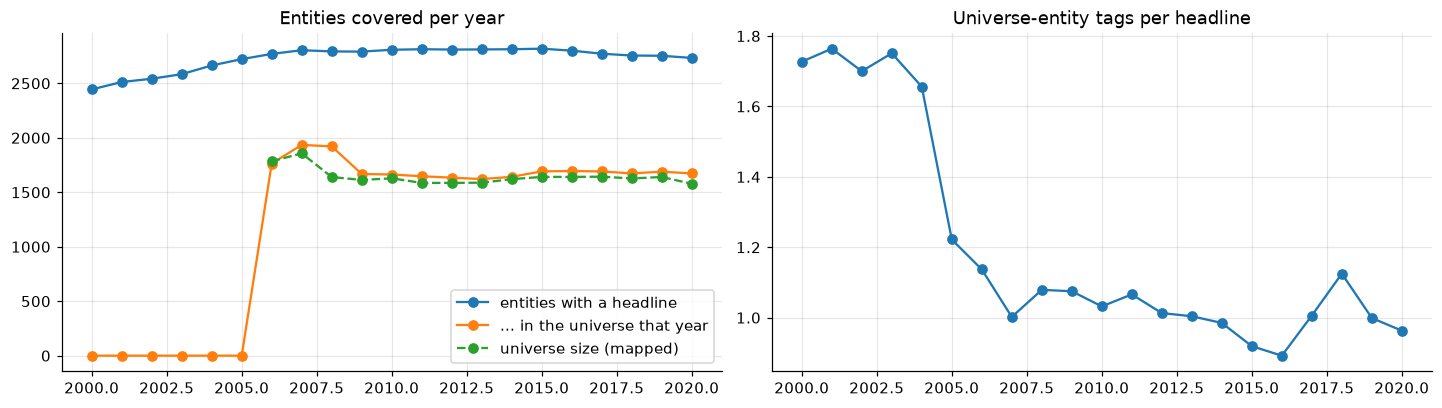

In [21]:
by_entity_year = (AA.group_by(pl.col("DATE").dt.year().alias("year"), "RP_ENTITY_ID")
                  .agg(pl.col("N_STORIES").sum(), pl.col("IN_UNIVERSE").any().alias("member"))
                  .collect())
heads_year = (DIAG.group_by("DATE").agg(pl.col("N_HEADLINES").first())
              .group_by(pl.col("DATE").dt.year().alias("year")).agg(pl.col("N_HEADLINES").sum()))
snap_year = (UNIVERSE.drop_nulls("rp_entity_id")
             .with_columns(pl.col("snapshot_date").dt.year().alias("year"))
             .filter(pl.col("snapshot_date") == pl.col("snapshot_date").max().over("year"))
             .select("year", "rp_entity_id"))
uni_size = snap_year.group_by("year").agg(pl.len().alias("universe_size"))
covered = (snap_year.join(by_entity_year.rename({"RP_ENTITY_ID": "rp_entity_id"}),
                          on=["year", "rp_entity_id"], how="inner")
           .group_by("year").agg(pl.len().alias("n_covered")))
unmapped = (DIAG.sort("DATE").group_by(pl.col("DATE").dt.year().alias("year"))
            .agg(pl.col("N_UNMAPPED").last()))
coverage = (by_entity_year.group_by("year")
            .agg(pl.len().alias("entities"), pl.col("member").sum().alias("members"),
                 pl.col("N_STORIES").sum())
            .join(heads_year, on="year", how="left")
            .join(uni_size, on="year", how="left").join(covered, on="year", how="left")
            .join(unmapped, on="year", how="left")
            .with_columns((pl.col("N_STORIES") / pl.col("N_HEADLINES")).round(3).alias("tags_per_headline"),
                          (pl.col("n_covered") / pl.col("universe_size")).round(3).alias("covered"))
            .sort("year"))
print(coverage)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(coverage["year"], coverage["entities"], marker="o", label="entities with a headline")
ax[0].plot(coverage["year"], coverage["members"], marker="o", label="... in the universe that year")
ax[0].plot(coverage["year"], coverage["universe_size"], marker="o", ls="--", label="universe size (mapped)")
ax[0].legend(); ax[0].set_title("Entities covered per year")
ax[1].plot(coverage["year"], coverage["tags_per_headline"], marker="o")
ax[1].set_title("Universe-entity tags per headline")
plt.show()

## 1.4 Membership flag

Share of rows (and of stories) by IN_UNIVERSE value, per year. Before 2006-07 there is no
snapshot, so the flag is null and the reader decides: keep every entity ever in the
universe (the default below: no masking) or start member-only analyses in 2006-07.

In [22]:
member = (AA.group_by(pl.col("DATE").dt.year().alias("year"),
                      pl.col("IN_UNIVERSE").cast(pl.String).fill_null("null").alias("IN_UNIVERSE"))
          .agg(pl.len().alias("rows"), pl.col("N_STORIES").sum().alias("stories"))
          .collect()
          .with_columns((pl.col("stories") / pl.col("stories").sum().over("year")).round(3).alias("story_share"))
          .pivot(on="IN_UNIVERSE", index="year", values="story_share").sort("year"))
print(member)

shape: (21, 4)
┌──────┬───────┬───────┬───────┐
│ year ┆ true  ┆ false ┆ null  │
│ ---  ┆ ---   ┆ ---   ┆ ---   │
│ i32  ┆ f64   ┆ f64   ┆ f64   │
╞══════╪═══════╪═══════╪═══════╡
│ 2000 ┆ null  ┆ null  ┆ 1.0   │
│ 2001 ┆ null  ┆ null  ┆ 1.0   │
│ 2002 ┆ null  ┆ null  ┆ 1.0   │
│ 2003 ┆ null  ┆ null  ┆ 1.0   │
│ 2004 ┆ null  ┆ null  ┆ 1.0   │
│ 2005 ┆ null  ┆ null  ┆ 1.0   │
│ 2006 ┆ 0.407 ┆ 0.201 ┆ 0.391 │
│ 2007 ┆ 0.851 ┆ 0.149 ┆ null  │
│ 2008 ┆ 0.888 ┆ 0.112 ┆ null  │
│ 2009 ┆ 0.835 ┆ 0.165 ┆ null  │
│ 2010 ┆ 0.802 ┆ 0.198 ┆ null  │
│ 2011 ┆ 0.768 ┆ 0.232 ┆ null  │
│ 2012 ┆ 0.788 ┆ 0.212 ┆ null  │
│ 2013 ┆ 0.796 ┆ 0.204 ┆ null  │
│ 2014 ┆ 0.843 ┆ 0.157 ┆ null  │
│ 2015 ┆ 0.884 ┆ 0.116 ┆ null  │
│ 2016 ┆ 0.885 ┆ 0.115 ┆ null  │
│ 2017 ┆ 0.884 ┆ 0.116 ┆ null  │
│ 2018 ┆ 0.893 ┆ 0.107 ┆ null  │
│ 2019 ┆ 0.888 ┆ 0.112 ┆ null  │
│ 2020 ┆ 0.887 ┆ 0.113 ┆ null  │
└──────┴───────┴───────┴───────┘


## 1.5 Relevance

How much of the attention survives the relevance floor, per year and per label:
`rel_share` = Σ N_STORIES_REL / Σ N_STORIES, `mean_rel` = Σ REL_SUM / Σ N_STORIES (mean
vendor relevance / 100). Then the distribution, across (entity, year), of the entity's
relevant share: entities mostly mentioned in passing sit on the left.

shape: (21, 4)
┌──────┬───────┬───────┬───────┐
│ year ┆ neu   ┆ pos   ┆ neg   │
│ ---  ┆ ---   ┆ ---   ┆ ---   │
│ i32  ┆ f64   ┆ f64   ┆ f64   │
╞══════╪═══════╪═══════╪═══════╡
│ 2000 ┆ 0.136 ┆ 0.299 ┆ 0.207 │
│ 2001 ┆ 0.145 ┆ 0.323 ┆ 0.224 │
│ 2002 ┆ 0.188 ┆ 0.398 ┆ 0.298 │
│ 2003 ┆ 0.175 ┆ 0.425 ┆ 0.327 │
│ 2004 ┆ 0.149 ┆ 0.393 ┆ 0.334 │
│ 2005 ┆ 0.211 ┆ 0.445 ┆ 0.383 │
│ 2006 ┆ 0.208 ┆ 0.39  ┆ 0.289 │
│ 2007 ┆ 0.208 ┆ 0.347 ┆ 0.245 │
│ 2008 ┆ 0.251 ┆ 0.372 ┆ 0.285 │
│ 2009 ┆ 0.243 ┆ 0.354 ┆ 0.287 │
│ 2010 ┆ 0.256 ┆ 0.377 ┆ 0.314 │
│ 2011 ┆ 0.254 ┆ 0.371 ┆ 0.289 │
│ 2012 ┆ 0.236 ┆ 0.333 ┆ 0.258 │
│ 2013 ┆ 0.218 ┆ 0.306 ┆ 0.224 │
│ 2014 ┆ 0.196 ┆ 0.293 ┆ 0.213 │
│ 2015 ┆ 0.185 ┆ 0.291 ┆ 0.197 │
│ 2016 ┆ 0.18  ┆ 0.294 ┆ 0.194 │
│ 2017 ┆ 0.18  ┆ 0.298 ┆ 0.211 │
│ 2018 ┆ 0.185 ┆ 0.266 ┆ 0.2   │
│ 2019 ┆ 0.204 ┆ 0.273 ┆ 0.215 │
│ 2020 ┆ 0.178 ┆ 0.277 ┆ 0.192 │
└──────┴───────┴───────┴───────┘


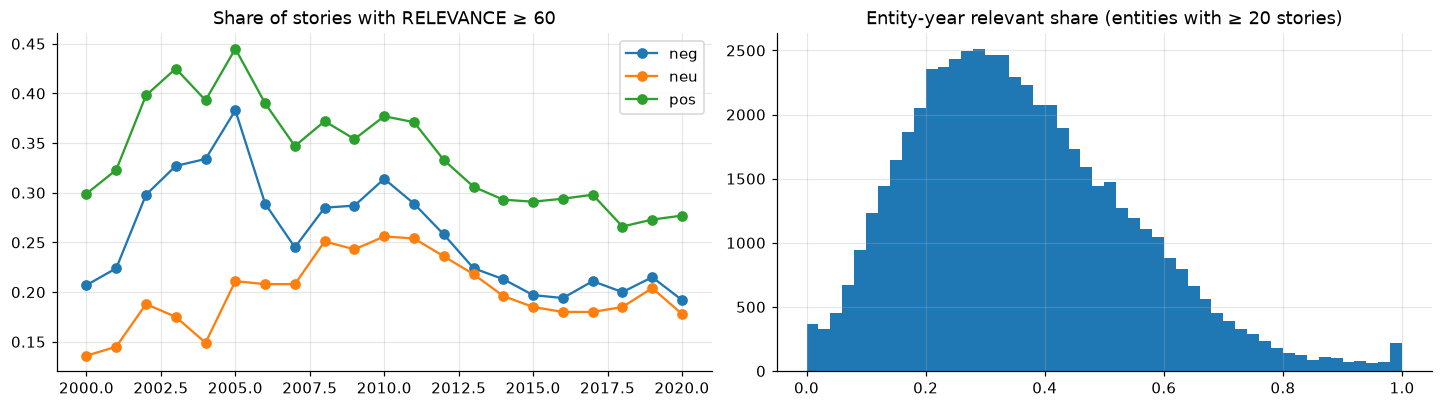

In [23]:
rel = (AA.group_by(pl.col("DATE").dt.year().alias("year"), "SENTIMENT")
       .agg(pl.col("N_STORIES").sum(), pl.col("N_STORIES_REL").sum(), pl.col("REL_SUM").sum())
       .collect()
       .with_columns((pl.col("N_STORIES_REL") / pl.col("N_STORIES")).round(3).alias("rel_share"),
                     (pl.col("REL_SUM") / pl.col("N_STORIES")).round(3).alias("mean_rel")))
print(rel.pivot(on="SENTIMENT", index="year", values="rel_share").sort("year"))

ent_rel = (AA.group_by(pl.col("DATE").dt.year().alias("year"), "RP_ENTITY_ID")
           .agg(pl.col("N_STORIES").sum(), pl.col("N_STORIES_REL").sum())
           .filter(pl.col("N_STORIES") >= 20)
           .with_columns((pl.col("N_STORIES_REL") / pl.col("N_STORIES")).alias("rel_share"))
           .collect())
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for lab in ("neg", "neu", "pos"):
    r = rel.filter(pl.col("SENTIMENT") == lab).sort("year")
    ax[0].plot(r["year"], r["rel_share"], marker="o", label=lab)
ax[0].legend(); ax[0].set_title("Share of stories with RELEVANCE ≥ 60")
ax[1].hist(ent_rel["rel_share"], bins=50)
ax[1].set_title("Entity-year relevant share (entities with ≥ 20 stories)")
plt.show()

## 1.6 Helpers for the cases

`attention(window, labels)`: Σ over the window of the label set's N_STORIES (plain and
relevant) per entity, divided by Σ N_HEADLINES of the window's days (from the
diagnostics, so days without any asset row still count). `weekly(ids, labels)`: the same
per ISO week, for a few entities.

In [24]:
DAY_HEADS = DIAG.group_by("DATE").agg(pl.col("N_HEADLINES").first()).sort("DATE")


def window_headlines(window) -> int:
    lo, hi = window
    return int(DAY_HEADS.filter(pl.col("DATE").is_between(lo, hi))["N_HEADLINES"].sum())


def attention(window, labels) -> pl.DataFrame:
    # per entity: stories of the label set over the window, and shares of the window's flow
    lo, hi = window
    n = window_headlines(window)
    if n == 0:
        print(f"no scored day in {lo} .. {hi}")
        return pl.DataFrame()
    return (AA.filter(pl.col("DATE").is_between(lo, hi), pl.col("SENTIMENT").is_in(list(labels)))
            .group_by("RP_ENTITY_ID")
            .agg(pl.col("N_STORIES").sum(), pl.col("N_STORIES_REL").sum(), pl.col("REL_SUM").sum())
            .collect()
            .with_columns((pl.col("N_STORIES") / n).alias("share"),
                          (pl.col("N_STORIES_REL") / n).alias("share_rel"))
            .join(ENTITIES, on="RP_ENTITY_ID", how="left"))


def top_attention(case, labels, n=TOP_N, by="share") -> pl.DataFrame:
    # top entities of the window by `by` (share or share_rel), with the baseline and the ratio
    win = attention(case["window"], labels)
    if win.is_empty():
        return win
    base = attention(case["baseline"], labels).select("RP_ENTITY_ID", pl.col(by).alias("share_base"))
    return (win.join(base, on="RP_ENTITY_ID", how="left")
            .with_columns((pl.col(by) / pl.col("share_base")).alias("ratio"))
            .sort(by, descending=True).head(n)
            .select("name", "ticker", "gics_sector", "N_STORIES", "N_STORIES_REL",
                    (pl.col(by) * 1e3).round(3).alias(f"{by}_permille"),
                    (pl.col("share_base") * 1e3).round(3).alias("base_permille"),
                    pl.col("ratio").round(1)))


def weekly(ids, labels, view) -> pl.DataFrame:
    # per ISO week (Monday) and entity: stories of the label set / the week's headlines
    lo, hi = view
    heads = (DAY_HEADS.filter(pl.col("DATE").is_between(lo, hi))
             .group_by(pl.col("DATE").dt.truncate("1w").alias("WEEK")).agg(pl.col("N_HEADLINES").sum()))
    st = (AA.filter(pl.col("DATE").is_between(lo, hi), pl.col("SENTIMENT").is_in(list(labels)),
                    pl.col("RP_ENTITY_ID").is_in(list(ids)))
          .group_by(pl.col("DATE").dt.truncate("1w").alias("WEEK"), "RP_ENTITY_ID")
          .agg(pl.col("N_STORIES").sum())
          .collect())
    grid = heads.join(pl.DataFrame({"RP_ENTITY_ID": list(ids)}), how="cross")
    return (grid.join(st, on=["WEEK", "RP_ENTITY_ID"], how="left")
            .with_columns(pl.col("N_STORIES").fill_null(0))
            .with_columns((pl.col("N_STORIES") / pl.col("N_HEADLINES")).alias("share"))
            .sort("RP_ENTITY_ID", "WEEK"))


def plot_weekly(case, labels, title, logy=True):
    names = case["names"]
    w = weekly(names.values(), labels, case["view"])
    if w.is_empty():
        print(f"{title}: no data in the view yet")
        return
    n = len(names)
    ncols = 3
    fig, axes = plt.subplots((n + ncols - 1) // ncols, ncols, figsize=(14, 2.3 * ((n + ncols - 1) // ncols)),
                             sharex=True)
    for ax, (label, eid) in zip(axes.flat, names.items()):
        s = w.filter(pl.col("RP_ENTITY_ID") == eid)
        ax.plot(s["WEEK"], s["share"] * 1e3, lw=1)
        for d in case["events"].values():
            ax.axvline(d, color="k", lw=0.5, ls="--")
        if logy and (s["share"] > 0).any():
            ax.set_yscale("log")
        ax.set_title(label, fontsize=9)
        ax.xaxis.set_major_locator(mdates.YearLocator())
    for ax in list(axes.flat)[n:]:
        ax.set_visible(False)
    fig.suptitle(f"{title}: weekly attention share (‰ of headlines)")
    plt.show()


def tone(case, window) -> pl.DataFrame:
    # per case entity: Negative vs Positive+neutral stories over the window and the baseline
    rows = []
    for tag, win in (("base", case["baseline"]), ("window", window)):
        lo, hi = win
        t = (AA.filter(pl.col("DATE").is_between(lo, hi), pl.col("RP_ENTITY_ID").is_in(list(case["names"].values())))
             .group_by("RP_ENTITY_ID")
             .agg(pl.col("N_STORIES").sum().alias("all"),
                  pl.col("N_STORIES").filter(pl.col("SENTIMENT") == "neg").sum().alias("neg"))
             .collect()
             .with_columns((pl.col("neg") / pl.col("all")).alias(f"neg_share_{tag}"),
                           pl.col("all").alias(f"stories_{tag}"))
             .select("RP_ENTITY_ID", f"stories_{tag}", f"neg_share_{tag}"))
        rows.append(t)
    names = pl.DataFrame({"case_name": list(case["names"]), "RP_ENTITY_ID": list(case["names"].values())})
    return (names.join(rows[0], on="RP_ENTITY_ID", how="left").join(rows[1], on="RP_ENTITY_ID", how="left")
            .with_columns(pl.col("^neg_share_.*$").round(3),
                          (pl.col("neg_share_window") - pl.col("neg_share_base")).round(3).alias("Δneg_share")))


def sectors(case, labels) -> pl.DataFrame:
    # GICS sector shares of the flow, window vs baseline (entities with no sector: "n/a")
    out = []
    for tag, win in (("base", case["baseline"]), ("window", case["window"])):
        a = attention(win, labels)
        if a.is_empty():
            return a
        out.append(a.with_columns(pl.col("gics_sector").fill_null("n/a"))
                   .group_by("gics_sector").agg((pl.col("share").sum() * 1e3).alias(f"permille_{tag}")))
    return (out[0].join(out[1], on="gics_sector", how="full", coalesce=True)
            .with_columns((pl.col("permille_window") / pl.col("permille_base")).round(2).alias("ratio"),
                          pl.col("^permille_.*$").round(2))
            .sort("permille_window", descending=True, nulls_last=True))

# Part 2: GFC

## 2.1 Who took the attention: top entities, Lehman → coordinated cut (Sep–Oct 2008)

Shares in ‰ of all headlines of the window, with the 2007H1 baseline and the ratio. Three
studies, the same as the narrative notebooks: Attention (every label), Negative,
Positive + neutral.

Two rankings: by all stories (`share`) and by relevant stories only (`share_rel`,
RELEVANCE ≥ 60). Publishers and venues (Thomson Reuters, LSEG, Nasdaq, NYSE) are tagged on
a large part of the flow with near-zero relevance: they lead the first ranking and vanish
from the second.

In [25]:
for study, labels in STUDIES.items():
    for by in ("share", "share_rel"):
        print(f"\n=== {study} ({' + '.join(labels)}), by {by} ===")
        print(top_attention(GFC, labels, by=by))


=== Attention (neg + neu + pos), by share ===
shape: (20, 8)
┌────────────────────────────────────────┬────────┬────────────────────────┬───────────┬───────────────┬────────────────┬───────────────┬───────┐
│ name                                   ┆ ticker ┆ gics_sector            ┆ N_STORIES ┆ N_STORIES_REL ┆ share_permille ┆ base_permille ┆ ratio │
│ ---                                    ┆ ---    ┆ ---                    ┆ ---       ┆ ---           ┆ ---            ┆ ---           ┆ ---   │
│ str                                    ┆ str    ┆ str                    ┆ i32       ┆ i32           ┆ f64            ┆ f64           ┆ f64   │
╞════════════════════════════════════════╪════════╪════════════════════════╪═══════════╪═══════════════╪════════════════╪═══════════════╪═══════╡
│ Thomson Reuters Corporation            ┆ TRI    ┆ Industrials            ┆ 222049    ┆ 100           ┆ 94.006         ┆ 10.664        ┆ 8.8   │
│ Lehman Brothers Holdings, Inc.         ┆ LEH    ┆ Financials

## 2.2 Named institutions through the crisis

Weekly attention share (log scale), events dashed. Bear Stearns stops at its absorption by
JPMorgan (2008-05), Lehman at its bankruptcy; the GSEs peak at the conservatorship.

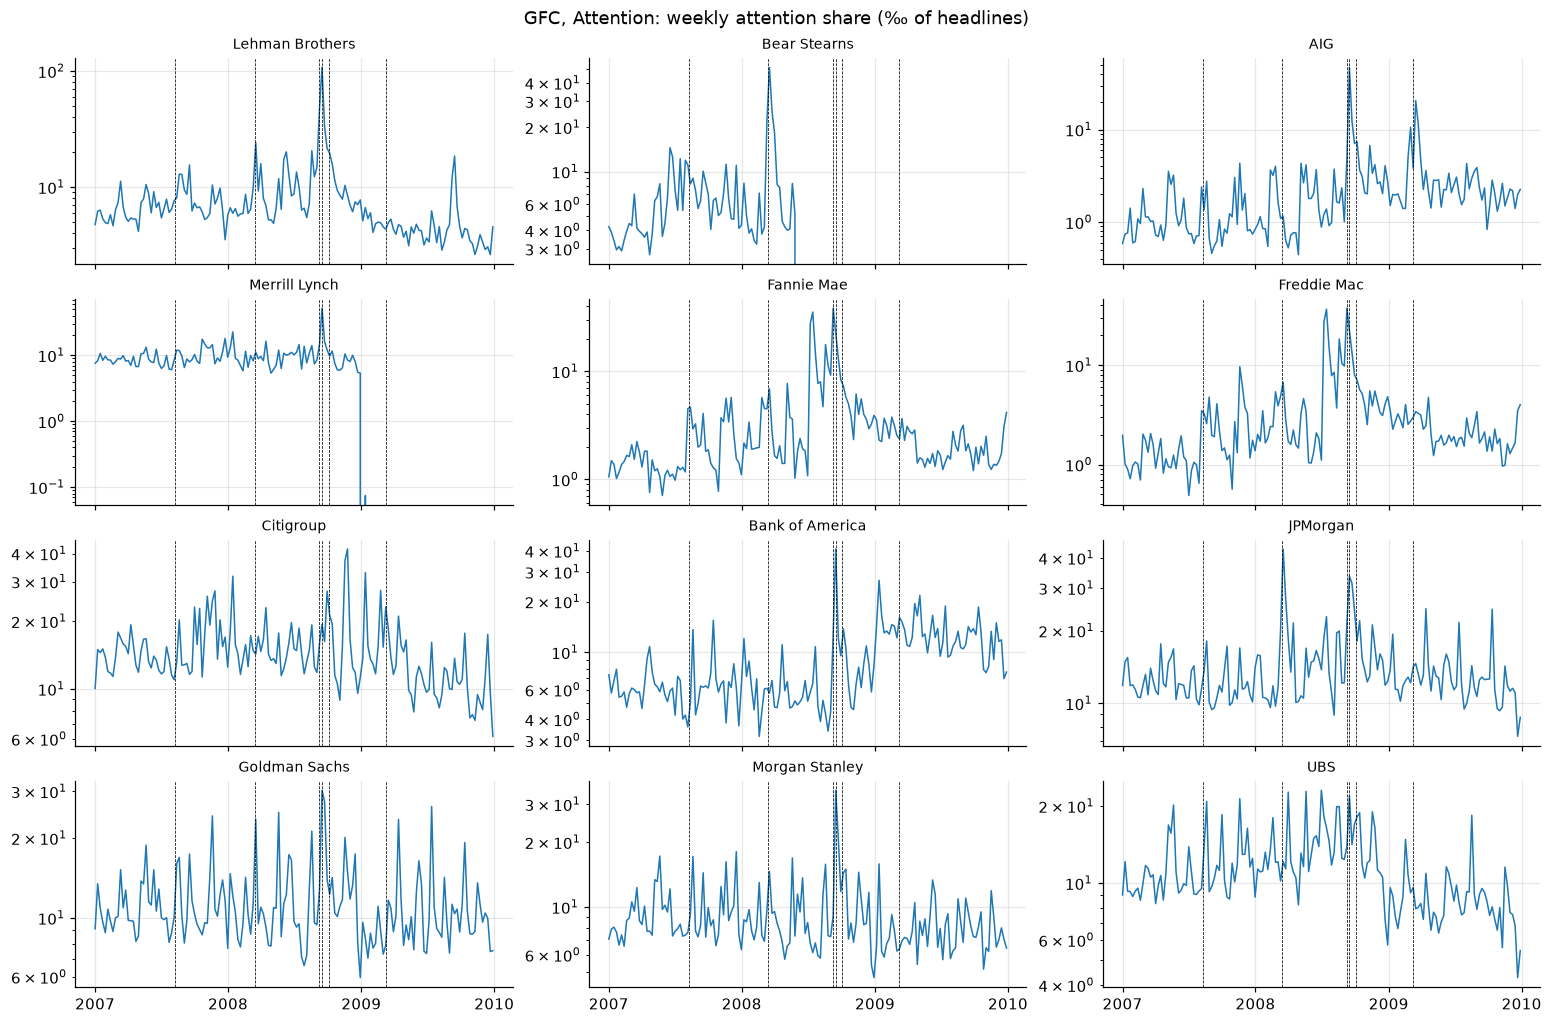

In [26]:
plot_weekly(GFC, STUDIES["Attention"], "GFC, Attention")

## 2.3 Tone: negative share of each institution's stories

Σ neg N_STORIES / Σ N_STORIES (all labels), baseline vs window. The negative study's split
of the same flow; a rise is the crisis read as bad news *about the name*.

In [27]:
print(tone(GFC, GFC["window"]))

shape: (12, 7)
┌─────────────────┬──────────────┬──────────────┬────────────────┬────────────────┬──────────────────┬────────────┐
│ case_name       ┆ RP_ENTITY_ID ┆ stories_base ┆ neg_share_base ┆ stories_window ┆ neg_share_window ┆ Δneg_share │
│ ---             ┆ ---          ┆ ---          ┆ ---            ┆ ---            ┆ ---              ┆ ---        │
│ str             ┆ str          ┆ i32          ┆ f64            ┆ i32            ┆ f64              ┆ f64        │
╞═════════════════╪══════════════╪══════════════╪════════════════╪════════════════╪══════════════════╪════════════╡
│ Lehman Brothers ┆ A78640       ┆ 39600        ┆ 0.141          ┆ 73181          ┆ 0.337            ┆ 0.196      │
│ Bear Stearns    ┆ A94325       ┆ 31098        ┆ 0.181          ┆ null           ┆ null             ┆ null       │
│ AIG             ┆ 0BC29E       ┆ 7845         ┆ 0.119          ┆ 23120          ┆ 0.367            ┆ 0.248      │
│ Merrill Lynch   ┆ 75EE05       ┆ 53879        ┆ 0.134  

## 2.4 Sectors

GICS sectors (as last known) of the window's attention vs the baseline: Financials should
take most of the flow and gain the most.

In [28]:
for study in ("Attention", "Negative"):
    print(f"\n=== {study} ===")
    print(sectors(GFC, STUDIES[study]))


=== Attention ===
shape: (12, 4)
┌────────────────────────┬───────────────┬─────────────────┬───────┐
│ gics_sector            ┆ permille_base ┆ permille_window ┆ ratio │
│ ---                    ┆ ---           ┆ ---             ┆ ---   │
│ str                    ┆ f64           ┆ f64             ┆ f64   │
╞════════════════════════╪═══════════════╪═════════════════╪═══════╡
│ Financials             ┆ 310.3         ┆ 448.84          ┆ 1.45  │
│ Industrials            ┆ 85.71         ┆ 163.52          ┆ 1.91  │
│ Consumer Discretionary ┆ 174.08        ┆ 114.66          ┆ 0.66  │
│ n/a                    ┆ 96.31         ┆ 99.43           ┆ 1.03  │
│ Information Technology ┆ 96.09         ┆ 88.62           ┆ 0.92  │
│ Communication Services ┆ 63.86         ┆ 69.95           ┆ 1.1   │
│ Materials              ┆ 34.47         ┆ 49.99           ┆ 1.45  │
│ Health Care            ┆ 41.63         ┆ 40.19           ┆ 0.97  │
│ Energy                 ┆ 35.93         ┆ 37.07           ┆ 1.03  │


# Part 3: Covid

## 3.1 Top entities, Italy outbreak → negative WTI (24 Feb – 30 Apr 2020)

Baseline 2019H2. Expected: travel (airlines, cruise lines), oil majors, vaccine makers and
the stay-at-home winners gain; the very large names (Amazon, Apple, ...) stay near the top
throughout.

In [29]:
for study, labels in STUDIES.items():
    for by in ("share", "share_rel"):
        print(f"\n=== {study} ({' + '.join(labels)}), by {by} ===")
        print(top_attention(COVID, labels, by=by))


=== Attention (neg + neu + pos), by share ===
shape: (20, 8)
┌───────────────────────────────┬────────┬────────────────────────┬───────────┬───────────────┬────────────────┬───────────────┬───────┐
│ name                          ┆ ticker ┆ gics_sector            ┆ N_STORIES ┆ N_STORIES_REL ┆ share_permille ┆ base_permille ┆ ratio │
│ ---                           ┆ ---    ┆ ---                    ┆ ---       ┆ ---           ┆ ---            ┆ ---           ┆ ---   │
│ str                           ┆ str    ┆ str                    ┆ i32       ┆ i32           ┆ f64            ┆ f64           ┆ f64   │
╞═══════════════════════════════╪════════╪════════════════════════╪═══════════╪═══════════════╪════════════════╪═══════════════╪═══════╡
│ Twitter, Inc.                 ┆ TWTR   ┆ Communication Services ┆ 781058    ┆ 38574         ┆ 77.044         ┆ 82.042        ┆ 0.9   │
│ Meta Platforms, Inc.          ┆ META   ┆ Communication Services ┆ 746618    ┆ 101182        ┆ 73.647         ┆ 71.

## 3.2 Named companies through the pandemic

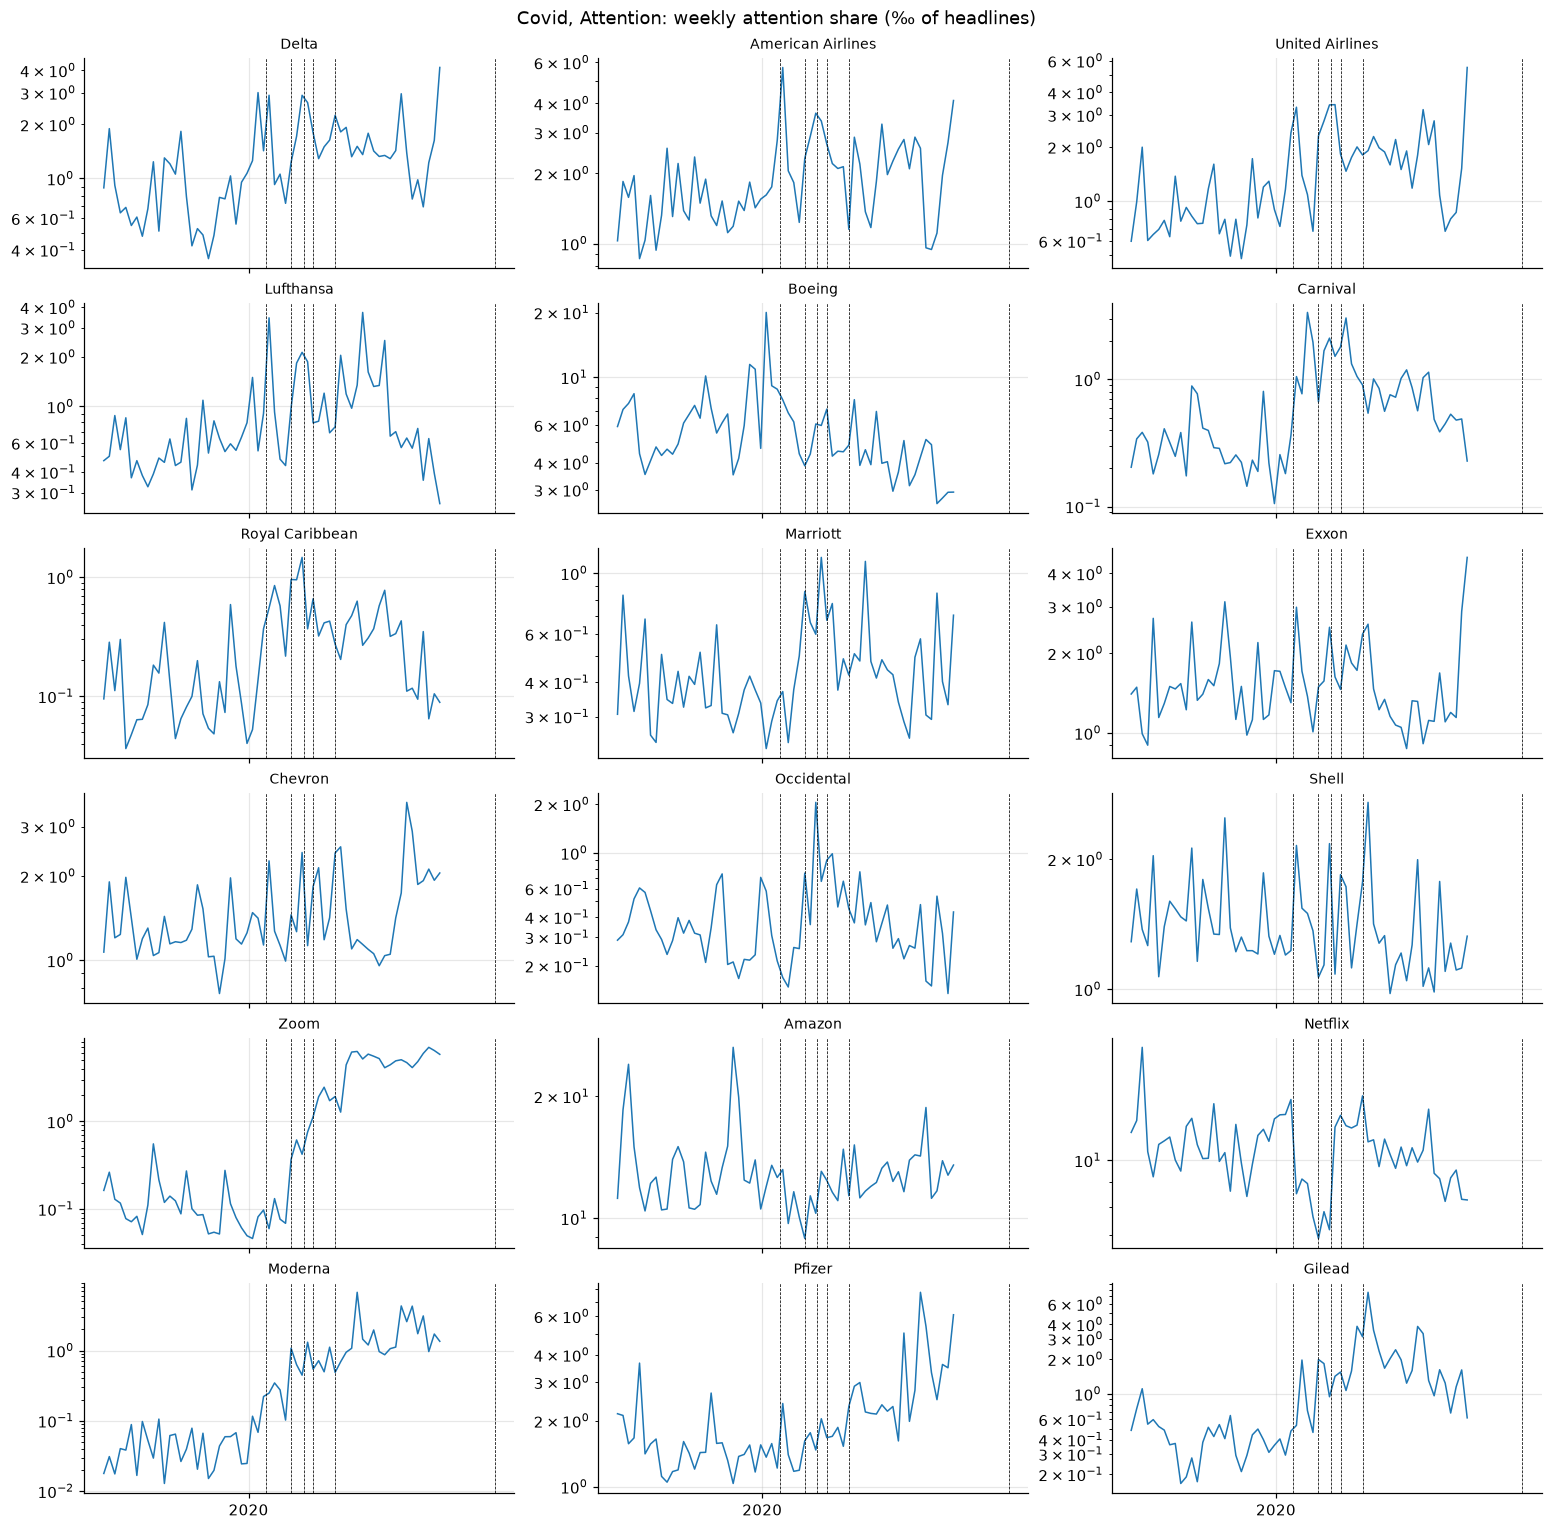

In [30]:
plot_weekly(COVID, STUDIES["Attention"], "Covid, Attention")

## 3.3 Tone

Expected: travel and energy names turn negative in the crash window; vaccine makers and
stay-at-home names stay positive or neutral. A second window around the Pfizer efficacy
news (Nov 2020) should show the travel names' negative share falling back.

In [31]:
print(tone(COVID, COVID["window"]))
print(tone(COVID, (date(2020, 11, 1), date(2020, 12, 15))))

shape: (18, 7)
┌───────────────────┬──────────────┬──────────────┬────────────────┬────────────────┬──────────────────┬────────────┐
│ case_name         ┆ RP_ENTITY_ID ┆ stories_base ┆ neg_share_base ┆ stories_window ┆ neg_share_window ┆ Δneg_share │
│ ---               ┆ ---          ┆ ---          ┆ ---            ┆ ---            ┆ ---              ┆ ---        │
│ str               ┆ str          ┆ i32          ┆ f64            ┆ i32            ┆ f64              ┆ f64        │
╞═══════════════════╪══════════════╪══════════════╪════════════════╪════════════════╪══════════════════╪════════════╡
│ Delta             ┆ 5F2FF7       ┆ 20057        ┆ 0.231          ┆ 18807          ┆ 0.476            ┆ 0.245      │
│ American Airlines ┆ 13C3E0       ┆ 36731        ┆ 0.356          ┆ 25382          ┆ 0.462            ┆ 0.106      │
│ United Airlines   ┆ 6E705B       ┆ 22434        ┆ 0.329          ┆ 22664          ┆ 0.539            ┆ 0.21       │
│ Lufthansa         ┆ 4DA329       ┆ 1394

## 3.4 Sectors

In [32]:
for study in ("Attention", "Negative"):
    print(f"\n=== {study} ===")
    print(sectors(COVID, STUDIES[study]))


=== Attention ===
shape: (12, 4)
┌────────────────────────┬───────────────┬─────────────────┬───────┐
│ gics_sector            ┆ permille_base ┆ permille_window ┆ ratio │
│ ---                    ┆ ---           ┆ ---             ┆ ---   │
│ str                    ┆ f64           ┆ f64             ┆ f64   │
╞════════════════════════╪═══════════════╪═════════════════╪═══════╡
│ Communication Services ┆ 308.45        ┆ 295.83          ┆ 0.96  │
│ Financials             ┆ 139.47        ┆ 168.62          ┆ 1.21  │
│ Industrials            ┆ 133.15        ┆ 142.19          ┆ 1.07  │
│ Consumer Discretionary ┆ 120.67        ┆ 114.33          ┆ 0.95  │
│ Information Technology ┆ 95.13         ┆ 84.99           ┆ 0.89  │
│ Health Care            ┆ 43.31         ┆ 52.88           ┆ 1.22  │
│ Consumer Staples       ┆ 33.08         ┆ 34.63           ┆ 1.05  │
│ n/a                    ┆ 29.19         ┆ 31.07           ┆ 1.06  │
│ Energy                 ┆ 16.46         ┆ 19.97           ┆ 1.21  │
